## Grid-Edge Analytics: VPP Capacity & Settlement Modeling

Analysis of California Residential Load Profiles for Virtual Power Plant (VPP) Development

### Executive Summary:
This notebook analyzes residential load profiles from the Open Energy Data Initiative (OEDI) to identify grid stress points in California’s distribution network. By identifying the Marginal Hour and simulating Measurement & Verification (M&V) protocols, this analysis provides the technical foundation for a "Capacity-as-a-Service" business model.

### Key Objectives:

1. Marginal Hour Identification: Differentiating between annual and seasonal peak stress.

2. M&V 2.0 Simulation: Calculating a "High 10-in-10" baseline to quantify "Negawatt" delivery.

3. Flexibility Assessment: Isolating controllable loads (HVAC/EV) as addressable VPP capacity.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
FILE_PATH = 'up00-ca-single-family_attached.csv'
TOTAL_LOAD_COL = 'out.electricity.total.energy_consumption..kwh'

def load_and_prep_data(path):
    """Loads the dataset and prepares the timestamp index."""
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

# Initialize Data
main_df = load_and_prep_data(FILE_PATH)
print("Data successfully loaded and timestamped.")

Data successfully loaded and timestamped.


### 1. Identifying the Marginal Hour
In a Uniform Price Market, the grid price is set by the most expensive "Marginal Unit" required to meet demand. By identifying the hours of maximum demand, we locate the points where a VPP adds the most value by displacing these expensive units with "Negawatts" (demand reduction).

--- ANNUAL Analysis ---
Peak Demand Hour: 22:00
Avg Peak Load:    309,858.31 kWh (309.858 MWh)
Market Insight:   Hour 22:00 represents the system stress peak.
------------------------------

--- SUMMER (JUL-SEP) Analysis ---
Peak Demand Hour: 21:00
Avg Peak Load:    349,746.76 kWh (349.747 MWh)
Market Insight:   Hour 21:00 represents the system stress peak.
------------------------------



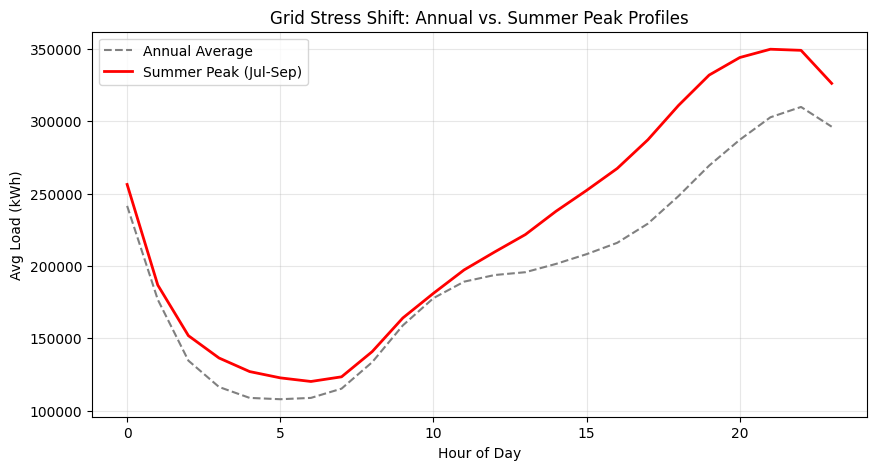

In [5]:
def analyze_grid_peak(df, period_label):
    """
    Calculates the hourly demand profile and identifies the peak stress hour.
    """
    # Group by hour and calculate average load
    hourly_avg = df.groupby(df['timestamp'].dt.hour)[TOTAL_LOAD_COL].mean()
    
    # Identify Peak Metrics
    peak_hour = hourly_avg.idxmax()
    peak_kwh = hourly_avg.max()
    peak_mwh = peak_kwh / 1000.0 
    
    print(f"--- {period_label} Analysis ---")
    print(f"Peak Demand Hour: {peak_hour}:00")
    print(f"Avg Peak Load:    {peak_kwh:,.2f} kWh ({peak_mwh:,.3f} MWh)")
    print(f"Market Insight:   Hour {peak_hour}:00 represents the system stress peak.")
    print("-" * 30 + "\n")
    
    return hourly_avg

# Annual Analysis
annual_profile = analyze_grid_peak(main_df, "ANNUAL")

# Summer Analysis (July - September)
summer_df = main_df[main_df['timestamp'].dt.month.isin([7, 8, 9])]
summer_profile = analyze_grid_peak(summer_df, "SUMMER (JUL-SEP)")

# Visualization of Seasonal Shift
plt.figure(figsize=(10, 5))
plt.plot(annual_profile, label='Annual Average', color='gray', linestyle='--')
plt.plot(summer_profile, label='Summer Peak (Jul-Sep)', color='red', linewidth=2)
plt.title("Grid Stress Shift: Annual vs. Summer Peak Profiles")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Load (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2. Measurement & Verification (M&V) Settlement
This simulation uses a High 10-in-10 Baseline. This is a standard utility methodology used to predict what usage would have been without intervention. The difference between the baseline and actual usage represents the "Negawatts" delivered, which forms the basis for financial settlement.

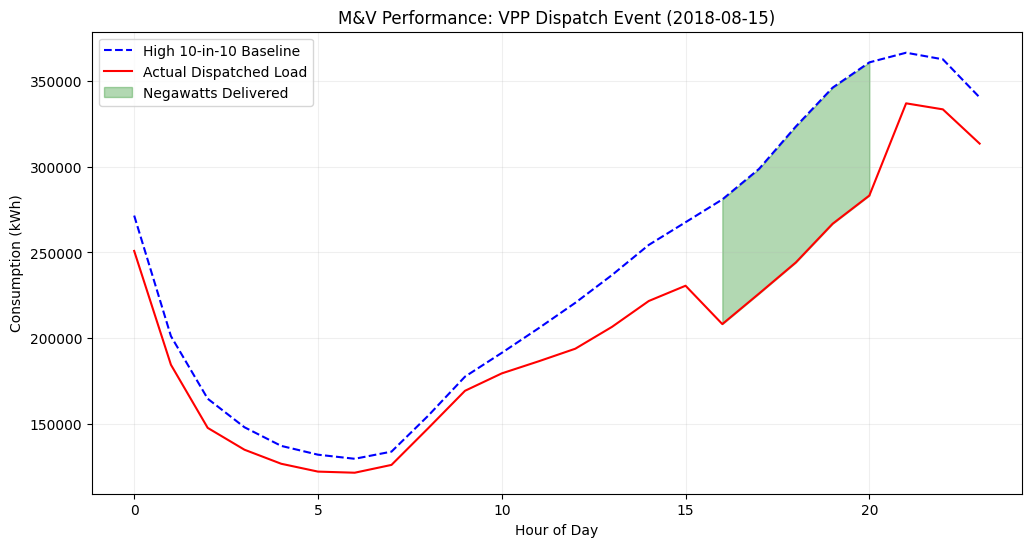

Total Event Performance: 381,402.59 kWh Delivered


In [6]:
def run_mv_analysis(df, event_date='2018-08-15'):
    """
    Calculates the High 10-in-10 Baseline and evaluates dispatch performance.
    """
    # Setup Timeframes
    df['date'] = df['timestamp'].dt.date
    df['is_weekday'] = df['timestamp'].dt.weekday < 5
    event_dt = pd.to_datetime(event_date).date()
    
    # Lookback: Find the 10 previous weekdays
    lookback_days = df[(df['date'] < event_dt) & (df['is_weekday'])].drop_duplicates('date').tail(10)['date']
    lookback_df = df[df['date'].isin(lookback_days)]
    
    # Calculate Baseline (Expected load)
    baseline = lookback_df.groupby(lookback_df['timestamp'].dt.hour)[TOTAL_LOAD_COL].mean()
    
    # Extract Actual Event Day Usage
    event_usage = df[df['date'] == event_dt].groupby(df['timestamp'].dt.hour)[TOTAL_LOAD_COL].mean()
    
    # Simulation: Assume a 15% Reduction during Peak (Hours 16-20)
    performance_window = range(16, 21)
    actual_performance = event_usage.copy()
    actual_performance.loc[actual_performance.index.isin(performance_window)] *= 0.85
    
    # Quantify Performance (Negawatts)
    negawatts = (baseline - actual_performance).clip(lower=0)
    total_savings = negawatts.loc[negawatts.index.isin(performance_window)].sum()
    
    # Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(baseline.index, baseline.values, label='High 10-in-10 Baseline', color='blue', linestyle='--')
    plt.plot(actual_performance.index, actual_performance.values, label='Actual Dispatched Load', color='red')
    plt.fill_between(baseline.index, actual_performance.values, baseline.values, 
                     where=(baseline.index.isin(performance_window)), color='green', alpha=0.3, label='Negawatts Delivered')
    
    plt.title(f"M&V Performance: VPP Dispatch Event ({event_date})")
    plt.xlabel("Hour of Day")
    plt.ylabel("Consumption (kWh)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    
    print(f"Total Event Performance: {total_savings:,.2f} kWh Delivered")
    return total_savings

# Running the M&V Analysis
mv_results = run_mv_analysis(main_df, event_date='2018-08-15')

### 3. Addressable VPP Capacity (Flexibility Ratio)
To provide a Firm Capacity guarantee, the orchestrator must isolate the loads that can be precisely controlled. In the residential sector, this addressable flexibility is primarily driven by HVAC and EV Charging loads.

In [7]:
def calculate_flexibility_ratio(df):
    """Isolates controllable loads during the summer peak."""
    summer_peak = df[df['timestamp'].dt.month.isin(range(6, 10))] # June to Sept
    
    # Controllable vs Total load comparison
    cooling = summer_peak['out.electricity.cooling.energy_consumption..kwh'].mean()
    ev = summer_peak['out.electricity.ev_charging.energy_consumption..kwh'].mean()
    total = summer_peak[TOTAL_LOAD_COL].mean()
    
    flex_ratio = (cooling + ev) / total
    
    print(f"--- Flexibility Assessment ---")
    print(f"Avg Summer Cooling Load: {cooling:,.2f} kWh")
    print(f"Avg Summer EV Load:      {ev:,.2f} kWh")
    print(f"Aggregated Flexibility:  {flex_ratio:.1%}")
    print("Interpretation: Significant summer peak load is controllable via DER orchestration.")

calculate_flexibility_ratio(main_df)

--- Flexibility Assessment ---
Avg Summer Cooling Load: 65,149.48 kWh
Avg Summer EV Load:      3,160.03 kWh
Aggregated Flexibility:  31.3%
Interpretation: Significant summer peak load is controllable via DER orchestration.
